# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [ ]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [1]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch04


In [2]:
!python --version

Python 3.12.10


In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

# Chapter 04 - Classification and regression
## 4.1 Classifying movie reviews: A binary classification example

`Two-class classification`, or `binary classification`, is one of the most common kinds of
machine learning problem. In this example, you’ll learn to classify movie reviews as
positive or negative, based on the text content of the reviews.



### 4.1.1 The IMDb dataset

You’ll work with the IMDb dataset: a set of 50,000 highly polarized reviews from the
Internet Movie Database. They’re split into 25,000 reviews for training and 25,000
reviews for testing, each set consisting of 50% negative and 50% positive reviews.

Just like the MNIST dataset, the IMDb dataset comes packaged with Keras. It has
already been preprocessed: the reviews (sequences of words) have been turned into
sequences of integers, where each integer stands for a specific word in a dictionary. This
enables us to focus on model building, training, and evaluation. In chapter 14, you’ll
learn how to process raw text input from scratch.

The following code will load the dataset (when you run it the first time, about 80 MB
of data will be downloaded to your machine).

In [4]:
# Listing 4.1 Loading the IMDb dataset

from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10_000)

The argument `num_words=10000` means you’ll only keep the top 10,000 most frequently
occurring words in the training data. Rare words will be discarded. This allows you to
work with vector data of manageable size. If we didn’t set this limit, we’d be working
with 88,585 unique words in the training data, which is unnecessarily large. Many of
these words only occur in a single sample, and thus can’t be meaningfully used for
classification.

The variables `train_data` and `test_data` are NumPy arrays of reviews; each review is a
list of word indices (encoding a sequence of words). `train_labels` and `test_labels` are
NumPy arrays of 0s and 1s, where `0` stands for `negative` and `1` stands for `positive`:

In [5]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [6]:
train_labels[0]

np.int64(1)

Because you’re restricting yourself to the top 10,000 most frequent words, no word
index will exceed 10,000:

In [7]:
max([max(sequence) for sequence in train_data])

9999

For kicks, let’s quickly decode one of these reviews back to English words

In [8]:
# Listing 4.2 Decoding reviews back to text

# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()

# Reverses it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# decodes the review. Note tht the indices are offset by 3 because 0, 1, and 2 are reversed
# indices for "padding", "start of sequence", and "unknown".
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])

Let’s take a look at what we got:

In [9]:
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

Note that the leading ? corresponds to a start token that has been prefixed to each
review.

### 4.1.2 Preparing the data

You can’t directly feed lists of integers into a neural network. They have all different
lengths, while a neural network expects to process contiguous batches of data. You
have to turn your lists into tensors. There are two ways to do that:

* Pad your lists so that they all have the same length, then turn them into an integer
tensor of shape (`samples, max_length`), and start your model with a layer
capable of handling such integer tensors (the `Embedding` layer, which we’ll cover
in detail later in the book).

* `Multi-hot encode` your lists to turn them into vectors of 0s and 1s reflecting the presence
or absence of all possible words. This would mean, for instance, turning the
sequence [8, 5] into a 10,000-dimensional vector that would be all 0s except for
indices 5 and 8, which would be 1s.

Let’s go with the latter solution to vectorize the data. When done manually, the process
looks like the following.

In [ ]:
# Listing 4.3 Encoding the Integer sequences via multi-hot encoding

import numpy as np


def multi_hot_encode(sequences, num_classes):
    # creates an all-zero matrix of shape (len(sequences), num_classes)
    results = np.zeros((len(sequences), num_classes))

    for i, sequence in enumerate(sequences):
        # sets specific indices of results[i] to 1s
        results[i][sequence] = 1.0
    return results


# vectorized training and test data
x_train = multi_hot_encode(train_data, num_classes=10_000)
x_test = multi_hot_encode(test_data, num_classes=10_000)


Here’s what the samples look like now:

In [11]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(10000,))

In addition to vectorizing the input sequences, you should also vectorize their labels,
which is straightforward. Our labels are already NumPy arrays, so just convert the type
from ints to floats:

In [12]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")


Now the data is ready to be fed into a neural network.

### 4.1.3 Building your model

The input data is vectors, and the labels are scalars (1s and 0s): this is one of the simplest
problem setups you’ll ever encounter. A type of model that performs well on such
a problem is a plain stack of densely connected (`Dense`) layers with `relu` activations.
There are two key architecture decisions to be made about such a stack of `Dense`
layers:

* How many layers to use

* How many units to choose for each layer

In chapter 5, you’ll learn formal principles to guide you in making these choices. For
the time being, you’ll have to trust us with the following architecture choice:

* Two intermediate layers with 16 units each

* A third layer that will output the scalar prediction regarding the sentiment of the
current review

<img src="../pics/fig_4_1.png" width=300> 


Figure 4.1 shows what the model looks like. Here’s the
Keras implementation, similar to the MNIST example you
saw previously.

In [13]:
# Listing 4.4 Model definition

import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

The first argument being passed to each `Dense` layer is the number of `units` in the layer:
the dimensionality of representation space of the layer. You remember from chapters 2
and 3 that each such `Dense` layer with a `relu` activation implements the following chain
of tensor operations:

```python
    output = relu(dot(input, W) + b)
```

Having 16 units means the weight matrix `W` will have shape (`input_dimension, 16`): the
dot product with `W` will project the input data onto a 16-dimensional representation
space (and then you’ll add the bias vector `b` and apply the `relu` operation). You can
intuitively understand the dimensionality of your representation space as “how much
freedom you’re allowing the model to have when learning internal representations.”
Having more units (a higher-dimensional representation space) allows your model to
learn more complex representations, but it makes the model more computationally
expensive and may lead to learning unwanted patterns (patterns that will improve performance
on the training data but not on the test data).

The intermediate layers use `relu` as their activation function, and the final layer uses
a `sigmoid` activation to output a probability (a score between 0 and 1, indicating how
likely the review is to be positive). A `relu` (rectified linear unit) is a function meant to
zero-out negative values (see figure 4.2), whereas a `sigmoid` “squashes” arbitrary values
into the [0, 1] interval (see figure 4.3), outputting something that can be interpreted
as a probability.

<img src="../pics/fig_4_2.png" width=800> 


#### What are activation functions, and why are they necessary?
Without an activation function like `relu` (also called a non-linearity), the `Dense` layer
would consist of two linear operations—a dot product and an addition:

```python
    output = dot(input, W) + b
```

So the layer could only learn `linear transformations` (`affine transformations`) of the
input data: the hypothesis space of the layer would be the set of all possible linear
transformations of the input data into a 16-dimensional space. Such a hypothesis
space is too restricted and wouldn’t benefit from multiple layers of representations
because a deep stack of linear layers would still implement a linear operation: adding
more layers wouldn’t extend the hypothesis space (as you saw in chapter 2).

To get access to a much richer hypothesis space that would benefit from deep representations,
you need a `non-linearity` or `activation function`. `relu` is the most popular
activation function in deep learning, but there are many other candidates, which all
come with similarly strange names: `prelu`, `elu`, and so on.

Finally, you need to choose a `loss function` and an `optimizer`. Because you’re facing
a binary classification problem and the output of your model is a probability (you
end your model with a `single-unit` layer with a `sigmoid` activation), it’s best to use the
`binary_crossentropy loss`. It isn’t the only viable choice: you could use, for instance,
`mean_squared_error`. But `crossentropy` is usually the best choice when you’re dealing
with models that output probabilities. `Crossentropy` is a quantity from the field of information
theory that measures the distance between probability distributions or, in this
case, between the `ground-truth` distribution and your `predictions`.

As for the choice of the `optimizer`, we’ll go with `adam`, which is usually a good default
choice for virtually any problem.

Here’s the step where you configure the model with the `adam` optimizer and the `binary_crossentropy` 
loss function. Note that you’ll also monitor `accuracy` during training.

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

### 4.1.4 Validating your approach

As you learned in chapter 3, a deep learning model should never be evaluated on its
training data—it’s standard practice to use a “validation set” to monitor the accuracy of
the model during training. Here, you’ll create a validation set by setting apart 10,000
samples from the original training data.

You might ask, why not simply use the test data to evaluate the model? That seems like
it would be easier. The reason is that you’re going to want to use the results you get on
the validation set to inform your next choices to improve training—for instance, your
choice of what model size to use or how many epochs to train for. When you start doing
this, your validation scores stop being an accurate reflection of the performance of the
model on brand-new data, since the model has been deliberately modified to perform
better on the validation data. It’s good to keep around a set of never-before-seen samples
that you can use to perform the final evaluation round in a completely unbiased
way, and that’s exactly what the test set is. We’ll talk more about this in the next chapter.

In [15]:
# Listing 4.6 Setting aside a validation set

x_val = x_train[:10_000]
partial_x_train = x_train[10_000:]
y_val = y_train[:10_000]
partial_y_train = y_train[10_000:]

You’ll now train the model for 20 epochs (20 iterations over all samples in the training
data), in mini-batches of 512 samples. At the same time, you’ll monitor loss and accuracy
on the 10,000 samples that you set apart. You do so by passing the validation data
as the `validation_data` argument to `model.fit()`.

In [ ]:
# Listing 4.7 Training your model

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.6379 - loss: 0.6318 - val_accuracy: 0.7843 - val_loss: 0.5328
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8628 - loss: 0.4408 - val_accuracy: 0.8731 - val_loss: 0.3880
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9257 - loss: 0.2828 - val_accuracy: 0.8790 - val_loss: 0.3107
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9431 - loss: 0.1978 - val_accuracy: 0.8877 - val_loss: 0.2866
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9574 - loss: 0.1517 - val_accuracy: 0.8860 - val_loss: 0.2848
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9700 - loss: 0.1197 - val_accuracy: 0.8835 - val_loss: 0.2954
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9774 - loss: 0.0970 - val_accuracy: 0.8816 - val_loss: 0.3115
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9852 - loss: 0.0779 - val_accuracy: 0.8810 - v

#### The validation_split argument

Instead of manually splitting out validation data from your training data and passing it
as the `validation_data` argument, you can also use the `validation_split` argument
in `fit()`. It specifies a fraction of the training data to use as validation data, like this:

In [19]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9994 - loss: 0.0060 - val_accuracy: 0.9536 - val_loss: 0.1752
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9994 - loss: 0.0057 - val_accuracy: 0.9522 - val_loss: 0.1782
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9994 - loss: 0.0051 - val_accuracy: 0.9516 - val_loss: 0.1858
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9995 - loss: 0.0047 - val_accuracy: 0.9518 - val_loss: 0.1903
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9995 - loss: 0.0044 - val_accuracy: 0.9514 - val_loss: 0.1932
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9995 - loss: 0.0041 - val_accuracy: 0.9506 - val_loss: 0.1960
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9996 - loss: 0.0037 - val_accuracy: 0.9512 - val_loss: 0.2003
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9997 - loss: 0.0034 - val_accuracy: 0.9502 - va

In this example, 20% of the samples in the `x_train` and `y_train` arrays are being
held out from training and used as validation data.

On CPU, this will take less than 2 seconds per epoch—training is over in 20 seconds.
At the end of every epoch, there is a slight pause as the model computes its loss and
accuracy on the 10,000 samples of the validation data.

Note that the call to` model.fit()` returns a History object, as you’ve seen in chapter 3. 
This object has a member `history`, which is a dictionary containing data about everything
that happened during training. Let’s look at it:

In [20]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

The dictionary contains four entries: one per metric that was being monitored during
training and during validation. In the following two listings, let’s use Matplotlib to plot
the training and validation loss side by side (see figure 4.4), as well as the training and
validation accuracy (see figure 4.5). Note that your own results may vary slightly due to
a different random initialization of your model.

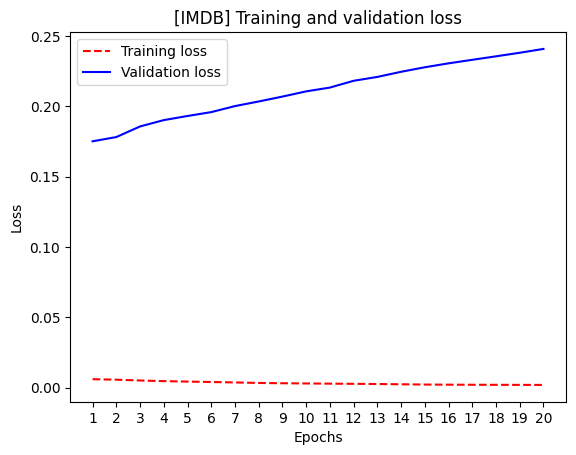

In [ ]:
# Listing 4.8 Plotting the training and validation loss

import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

# "b" is for solid blue line, "r--" is for dashed red line
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()


**Figure 4.4 Training and validation loss**

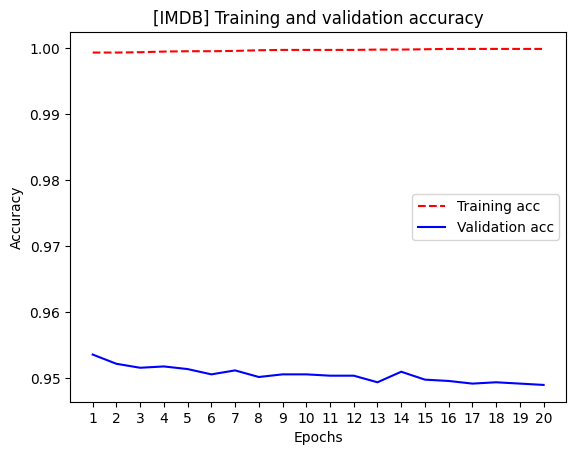

In [ ]:
# Listing 4.9 Plotting the training and validation accuracy

plt.clf()  # clears the figure
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Figure 4.5 Training and validation accuracy**

As you can see, the training loss decreases with every epoch, and the training accuracy
increases with every epoch. That’s what you would expect when running gradient-descent
optimization—the quantity you’re trying to minimize should be less with every
iteration. But that isn’t the case for the validation loss and accuracy: they seem to peak
at the fourth epoch. This is an example of what we warned against earlier: a model
that performs better on the training data isn’t necessarily a model that will do better
on data it has never seen before. In precise terms, what you’re seeing is overfitting: after
the fourth epoch, you’re overoptimizing on the training data, and you end up learning
representations that are specific to the training data and don’t generalize to data outside
of the training set.
In this case, to prevent overfitting, you could stop training after four epochs. In general,
you can use a range of techniques to mitigate overfitting, which we’ll cover in
chapter 5.
Let’s train a new model from scratch for four epochs and then evaluate it on the test
data.

In [23]:
# Listing 4.10 Training the model for four epochs

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7838 - loss: 0.5006
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9101 - loss: 0.2502
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9368 - loss: 0.1805
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9515 - loss: 0.1426
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8784 - loss: 0.3154  


The final results are as follows:

In [ ]:
results  # The first number, 0.31, is the test loss, and the second number, 0.87, is the test accuracy

[0.31539270281791687, 0.8784400224685669]

This fairly naive approach achieves an accuracy of 88%. With state-of-the-art
approaches, you should be able to get close to 95%.

### 4.1.5 Using a trained model to generate predictions on new data

After having trained a model, you’ll want to use it in a practical setting. You can generate
the likelihood of reviews being positive by using the predict method, as you’ve
learned in chapter 3:


In [25]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step  


array([[0.11821966],
       [0.999806  ],
       [0.7197833 ],
       ...,
       [0.10131023],
       [0.04828038],
       [0.7751294 ]], shape=(25000, 1), dtype=float32)

As you can see, the model is confident for some samples (0.99 or more, or 0.01 or less)
but less confident for others (0.6, 0.4).